In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.2)

sens_path = "analysis_outputs/sarcasm_coid/test/prediction_sensitivity_kl.csv"
pair_path = "analysis_outputs/sarcasm_coid/test/pairwise_component_skl.csv"

sens = pd.read_csv(sens_path)
pair = pd.read_csv(pair_path)


mkdir -p failed for path /home/tuanma5/.config/matplotlib: [Errno 13] Permission denied: '/home/tuanma5'
Matplotlib created a temporary cache directory at /tmp/matplotlib-bdhcyuts because there was an issue with the default path (/home/tuanma5/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


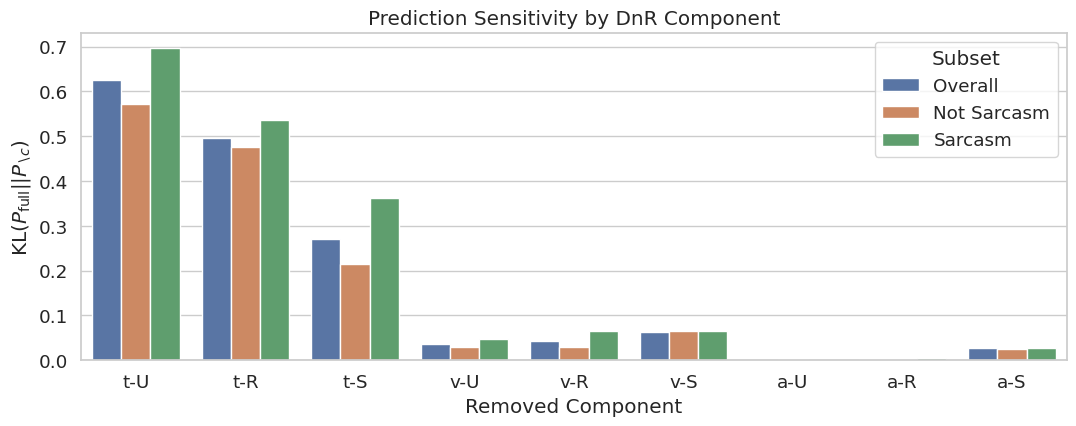

In [2]:
def weighted_mean(df, value_col):
    return np.average(df[value_col], weights=df["count"])

rows = []
for comp, group in sens.groupby("removed_component"):
    rows.append({
        "Component": comp,
        "Overall": weighted_mean(group, "mean_kl_full_to_removed"),
        "Not Sarcasm": weighted_mean(group, "mean_kl_not_sarcasm"),
        "Sarcasm": weighted_mean(group, "mean_kl_sarcasm"),
    })

plot_df = pd.DataFrame(rows)

order = ["t-U", "t-R", "t-S", "v-U", "v-R", "v-S", "a-U", "a-R", "a-S"]
plot_df["Component"] = pd.Categorical(plot_df["Component"], categories=order, ordered=True)
plot_df = plot_df.sort_values("Component")

long_df = plot_df.melt(
    id_vars="Component",
    value_vars=["Overall", "Not Sarcasm", "Sarcasm"],
    var_name="Subset",
    value_name="KL"
)

plt.figure(figsize=(11, 4.5))
ax = sns.barplot(data=long_df, x="Component", y="KL", hue="Subset")
ax.set_xlabel("Removed Component")
ax.set_ylabel(r"$\mathrm{KL}(P_{\mathrm{full}} || P_{\setminus c})$")
ax.set_title("Prediction Sensitivity by DnR Component")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("kld_prediction_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()


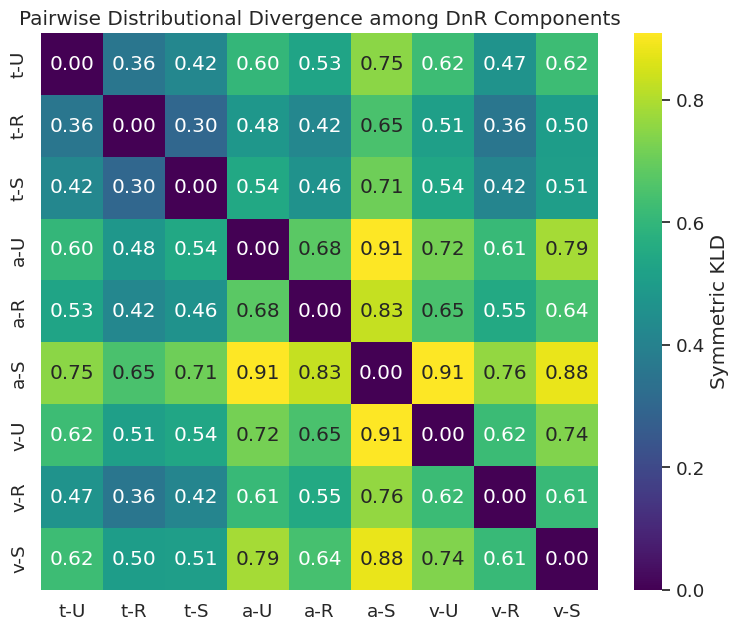

In [8]:
components = ["t-U", "t-R", "t-S", "a-U", "a-R", "a-S", "v-U", "v-R", "v-S"]

mat = pd.DataFrame(np.nan, index=components, columns=components, dtype=float)

agg = (
    pair.assign(weighted_skl=pair["mean_skl"] * pair["count"])
    .groupby(["left", "right"])
    .agg(total_skl=("weighted_skl", "sum"), total_count=("count", "sum"))
    .reset_index()
)

agg["skl"] = agg["total_skl"] / agg["total_count"]

for _, row in agg.iterrows():
    left = row["left"]
    right = row["right"]
    value = row["skl"]
    mat.loc[left, right] = value
    mat.loc[right, left] = value

for comp in components:
    mat.loc[comp, comp] = 0.0

plt.figure(figsize=(8, 6.5))
ax = sns.heatmap(
    mat,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Symmetric KLD"}
)
ax.set_title("Pairwise Distributional Divergence among DnR Components")
plt.tight_layout()
plt.savefig("pairwise_component_skl_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:
same_type_pairs = {
    "U": [("t-U", "a-U"), ("t-U", "v-U"), ("a-U", "v-U")],
    "R": [("t-R", "a-R"), ("t-R", "v-R"), ("a-R", "v-R")],
    "S": [("t-S", "a-S"), ("t-S", "v-S"), ("a-S", "v-S")],
}

lookup = {}
for _, row in agg.iterrows():
    lookup[(row["left"], row["right"])] = row["skl"]
    lookup[(row["right"], row["left"])] = row["skl"]

table_rows = []
for comp_type, pairs in same_type_pairs.items():
    values = [lookup[p] for p in pairs]
    table_rows.append({
        "Component Type": comp_type,
        "Text-Audio": values[0],
        "Text-Visual": values[1],
        "Audio-Visual": values[2],
        "Average": np.mean(values),
    })

cross_modal_df = pd.DataFrame(table_rows)
cross_modal_df


,Component Type,Text-Audio,Text-Visual,Audio-Visual,Average
0,U,0.603613,0.622131,0.717849,0.647864
1,R,0.422443,0.356268,0.548084,0.442265
2,S,0.708324,0.506906,0.879244,0.698158


In [5]:
within_pairs = {
    "Text": [("t-U", "t-R"), ("t-U", "t-S"), ("t-R", "t-S")],
    "Audio": [("a-U", "a-R"), ("a-U", "a-S"), ("a-R", "a-S")],
    "Visual": [("v-U", "v-R"), ("v-U", "v-S"), ("v-R", "v-S")],
}

table_rows = []
for modality, pairs in within_pairs.items():
    values = [lookup[p] for p in pairs]
    table_rows.append({
        "Modality": modality,
        "U-R": values[0],
        "U-S": values[1],
        "R-S": values[2],
    })

within_modal_df = pd.DataFrame(table_rows)
within_modal_df


,Modality,U-R,U-S,R-S
0,Text,0.355365,0.420669,0.298783
1,Audio,0.675736,0.909195,0.828156
2,Visual,0.618730,0.737597,0.614415


Saved.


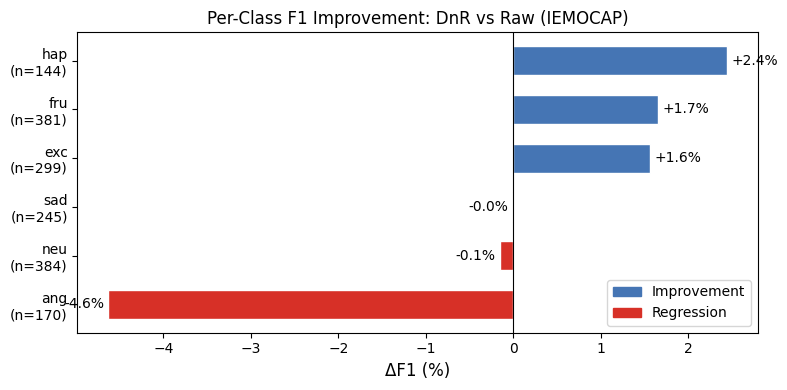

In [2]:
# analysis/plot_perclass.py
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv("analysis_outputs/iemocap_mmgcn/per_class/per_class_improvement.csv")
df = df.sort_values("delta", ascending=True)

colors = ["#d73027" if d < 0 else "#4575b4" for d in df["delta"]]
labels = [f"{e}\n(n={n})" for e, n in zip(df["emotion"], df["n_samples"])]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, df["delta"] * 100, color=colors, edgecolor="white", height=0.6)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("ΔF1 (%)", fontsize=12)
ax.set_title("Per-Class F1 Improvement: DnR vs Raw (IEMOCAP)", fontsize=12)

for bar, val in zip(bars, df["delta"] * 100):
    x = bar.get_width()
    ax.text(
        x + (0.05 if x >= 0 else -0.05),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.1f}%",
        va="center", ha="left" if x >= 0 else "right",
        fontsize=10,
    )

pos_patch = mpatches.Patch(color="#4575b4", label="Improvement")
neg_patch = mpatches.Patch(color="#d73027", label="Regression")
ax.legend(handles=[pos_patch, neg_patch], loc="lower right")

plt.tight_layout()
plt.savefig("figures/perclass_improvement.pdf", dpi=150, bbox_inches="tight")
plt.savefig("figures/perclass_improvement.png", dpi=150, bbox_inches="tight")
print("Saved.")